In [27]:
from IPython.display import display, Markdown

display(Markdown("""
# Spatiotemporal Analysis of Air Pollution (NO₂ and PM2.5)

This notebook analyzes how air pollution—specifically nitrogen dioxide (NO₂)  
and fine particulate matter (PM2.5)—varies over time and across locations  
using GEOS-CF virtual Zarr data.

## Objectives
- Extract and visualize 30-minute resolution data  
- Examine temporal trends over a selected one-week period  
- Understand daily (diurnal) patterns in pollution levels  
- Explore spatial variability around New York City  

**Author:** Siddharth Chaudhary
"""))


# Spatiotemporal Analysis of Air Pollution (NO₂ and PM2.5)

This notebook analyzes how air pollution—specifically nitrogen dioxide (NO₂)  
and fine particulate matter (PM2.5)—varies over time and across locations  
using GEOS-CF virtual Zarr data.

## Objectives
- Extract and visualize 30-minute resolution data  
- Examine temporal trends over a selected one-week period  
- Understand daily (diurnal) patterns in pollution levels  
- Explore spatial variability around New York City  

**Author:** Siddharth Chaudhary


In [4]:
import time
notebook_start = time.perf_counter()

import icechunk
import xarray as xr
import zarr

import numpy as np
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar


In [5]:
storage = icechunk.s3_storage(
    bucket='veda-geos-cf-virtualizarr',
    prefix="geos-cf-virtualizarr-data-pipelines/prod",
    anonymous=True,
    region="us-east-1",
)

URL_PREFIX = "https://ds.nccs.nasa.gov/thredds/fileServer/"

repo = icechunk.Repository.open(
    storage=storage,
    authorize_virtual_chunk_access={URL_PREFIX: None}
)

session = repo.readonly_session('main')
ds = xr.open_zarr(session.store, consolidated=False, zarr_format=3)
ds

/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 2TB
Dimensions:        (time: 53934, lev: 1, lat: 721, lon: 1440)
Coordinates:
  * time           (time) datetime64[ns] 431kB 2019-11-29T12:30:00 ... 2025-1...
  * lev            (lev) float64 8B 72.0
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO             (time, lev, lat, lon) float64 448GB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    SO2            (time, lev, lat, lon) float64 448GB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    NO2            (time, lev, lat, lon) float64 448GB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    O3             (time, lev, lat, lon) float64 448GB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    PM25_RH35_GCC  (time, lev, lat, lon) float64 448GB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>

In [7]:
print(ds.coords)
print(ds.data_vars)
print(ds["NO2"])
print(ds["PM25_RH35_GCC"])

Coordinates:
  * time     (time) datetime64[ns] 431kB 2019-11-29T12:30:00 ... 2025-11-18T1...
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO             (time, lev, lat, lon) float64 448GB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    SO2            (time, lev, lat, lon) float64 448GB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    NO2            (time, lev, lat, lon) float64 448GB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    O3             (time, lev, lat, lon) float64 448GB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    PM25_RH35_GCC  (time, lev, lat, lon) float64 448GB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
<xarray.DataArray 'NO2' (time: 53934, lev: 1, lat: 721, lon: 1440)> Size: 448GB
dask.array<open_dataset-NO2, shape=(53934, 1, 721, 1440), dtype=float64, 

In [14]:
ds.isel(time=0)['NO2'].compute()

<xarray.DataArray 'NO2' (lev: 1, lat: 721, lon: 1440)> Size: 8MB
array([[[1.28902000e-12, 1.28902000e-12, 1.28902000e-12, ...,
         1.28902000e-12, 1.28902000e-12, 1.28902000e-12],
        [8.52924393e-13, 8.52036215e-13, 8.50259858e-13, ...,
         8.56477107e-13, 8.54700750e-13, 8.53812572e-13],
        [4.39033277e-13, 4.37256920e-13, 4.35480563e-13, ...,
         4.44806437e-13, 4.43030080e-13, 4.41253723e-13],
        ...,
        [1.64251501e-12, 1.64251501e-12, 1.64429137e-12, ...,
         1.63718594e-12, 1.63896229e-12, 1.64073865e-12],
        [1.99423377e-12, 1.99423377e-12, 1.99423377e-12, ...,
         1.99423377e-12, 1.99423377e-12, 1.99423377e-12],
        [3.44374095e-12, 3.44374095e-12, 3.44374095e-12, ...,
         3.44374095e-12, 3.44374095e-12, 3.44374095e-12]]],
      shape=(1, 721, 1440))
Coordinates:
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    time     datetime64[ns] 8B 2019-11-29T12:30:00
Attributes:
    long_name:       Nitrogen dioxide (NO2, MW = 46.00 g mol-1) volume mixing...
    units:           mol mol-1
    fmissing_value:  999999986991104.0
    standard_name:   Nitrogen dioxide (NO2, MW = 46.00 g mol-1) volume mixing...
    vmin:            -999999986991104.0
    vmax:            999999986991104.0
    valid_range:     [-999999986991104.0, 999999986991104.0]

In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [11]:
ny_lat = 40.7128
ny_lon = -74.0060

start_time = "2024-07-01"
end_time   = "2024-07-08"

# Sort time first
ds = ds.sortby("time")

week_ds = ds.sel(time=slice(start_time, end_time))

ny_point = week_ds.sel(lat=ny_lat, lon=ny_lon, method="nearest").isel(lev=0)

print(ny_point)
print("Selected lat:", float(ny_point["lat"].values))
print("Selected lon:", float(ny_point["lon"].values))

<xarray.Dataset> Size: 9kB
Dimensions:        (time: 192)
Coordinates:
  * time           (time) datetime64[ns] 2kB 2024-07-01T00:30:00 ... 2024-07-...
    lat            float64 8B 40.75
    lev            float64 8B 72.0
    lon            float64 8B -74.0
Data variables:
    CO             (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    SO2            (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    NO2            (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    O3             (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    PM25_RH35_GCC  (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
Selected lat: 40.75
Selected lon: -74.0


In [13]:
no2_ts = ny_point["NO2"]
pm25_ts = ny_point["PM25_RH35_GCC"]

In [14]:
no2_ts = no2_ts.compute()
pm25_ts = pm25_ts.compute()

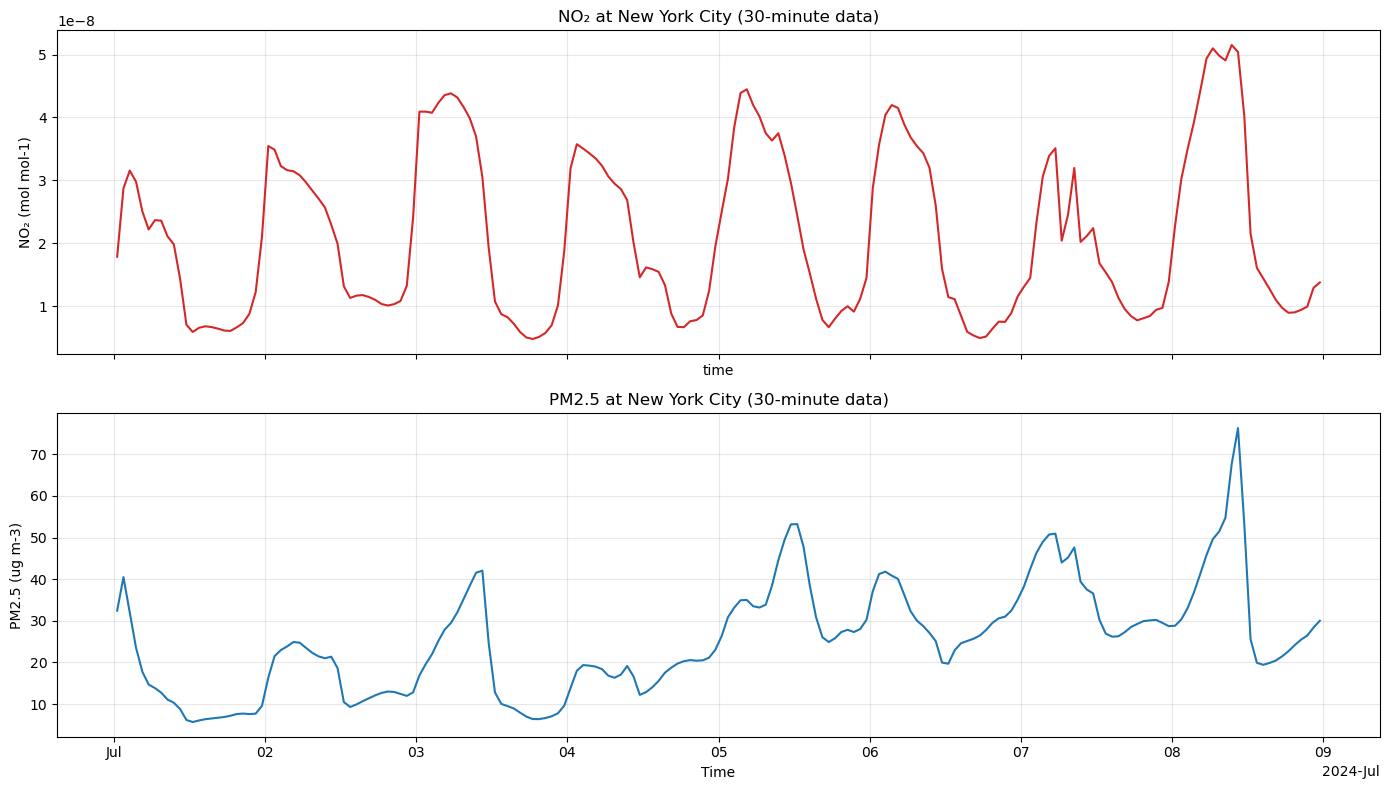

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

no2_ts.plot(ax=axes[0], color="tab:red")
axes[0].set_title("NO₂ at New York City (30-minute data)")
axes[0].set_ylabel(f"NO₂ ({no2_ts.attrs.get('units', 'unknown units')})")
axes[0].grid(True, alpha=0.3)

pm25_ts.plot(ax=axes[1], color="tab:blue")
axes[1].set_title("PM2.5 at New York City (30-minute data)")
axes[1].set_ylabel(f"PM2.5 ({pm25_ts.attrs.get('units', 'unknown units')})")
axes[1].set_xlabel("Time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

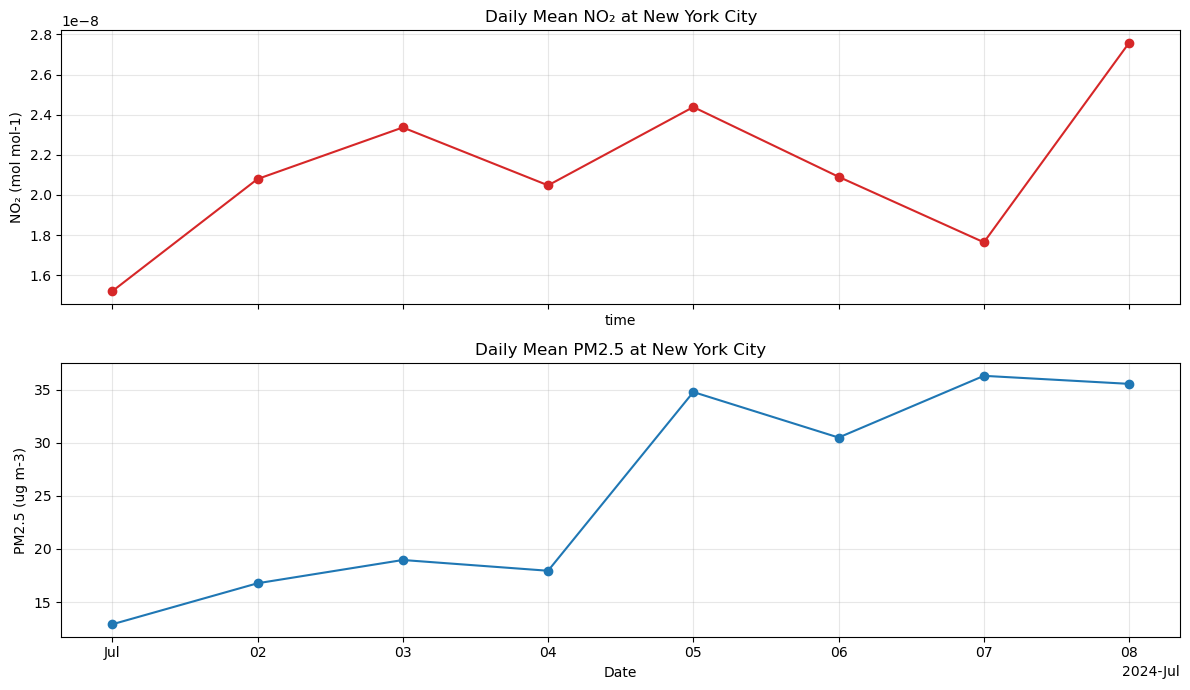

In [16]:
no2_daily = no2_ts.resample(time="1D").mean()
pm25_daily = pm25_ts.resample(time="1D").mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

no2_daily.plot(marker="o", ax=axes[0], color="tab:red")
axes[0].set_title("Daily Mean NO₂ at New York City")
axes[0].set_ylabel(f"NO₂ ({no2_daily.attrs.get('units', 'unknown units')})")
axes[0].grid(True, alpha=0.3)

pm25_daily.plot(marker="o", ax=axes[1], color="tab:blue")
axes[1].set_title("Daily Mean PM2.5 at New York City")
axes[1].set_ylabel(f"PM2.5 ({pm25_daily.attrs.get('units', 'unknown units')})")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
df = pd.DataFrame({
    "time": no2_ts["time"].values,
    "NO2": no2_ts.values,
    "PM25": pm25_ts.values
}).set_index("time")

display(df.head())

,NO2,PM25
time,,
2024-07-01 00:30:00,1.784066e-08,32.456814
2024-07-01 01:30:00,2.872549e-08,40.515228
2024-07-01 02:30:00,3.154856e-08,32.075737
2024-07-01 03:30:00,2.977323e-08,23.511555
2024-07-01 04:30:00,2.505841e-08,17.790506


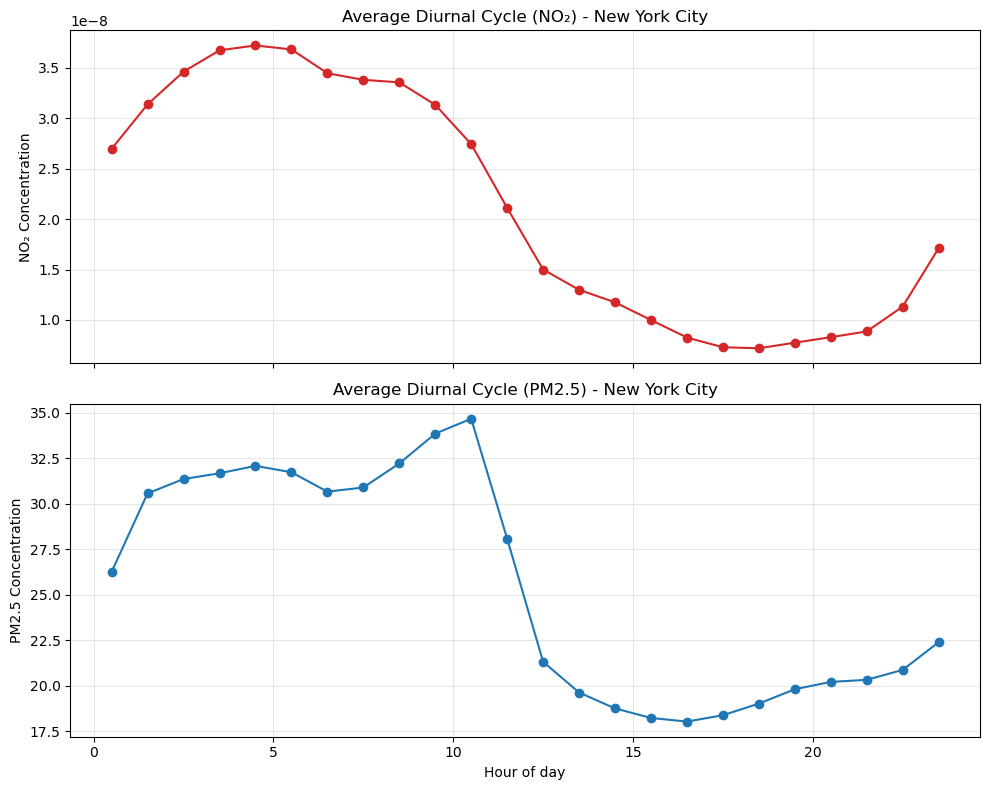

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# NO2
axes[0].plot(diurnal_mean.index, diurnal_mean["NO2"], marker="o", color="tab:red")
axes[0].set_title("Average Diurnal Cycle (NO₂) - New York City")
axes[0].set_ylabel("NO₂ Concentration")
axes[0].grid(True, alpha=0.3)

# PM2.5
axes[1].plot(diurnal_mean.index, diurnal_mean["PM25"], marker="o", color="tab:blue")
axes[1].set_title("Average Diurnal Cycle (PM2.5) - New York City")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("PM2.5 Concentration")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
lat_min, lat_max = 39.5, 41.5
lon_min, lon_max = -75.5, -72.5

region_ds = week_ds.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
).isel(lev=0)

In [21]:
sample_time = str(region_ds.time.values[0])
print("Sample time:", sample_time)

no2_map = region_ds["NO2"].isel(time=0).compute()
pm25_map = region_ds["PM25_RH35_GCC"].isel(time=0).compute()

Sample time: 2024-07-01T00:30:00.000000000


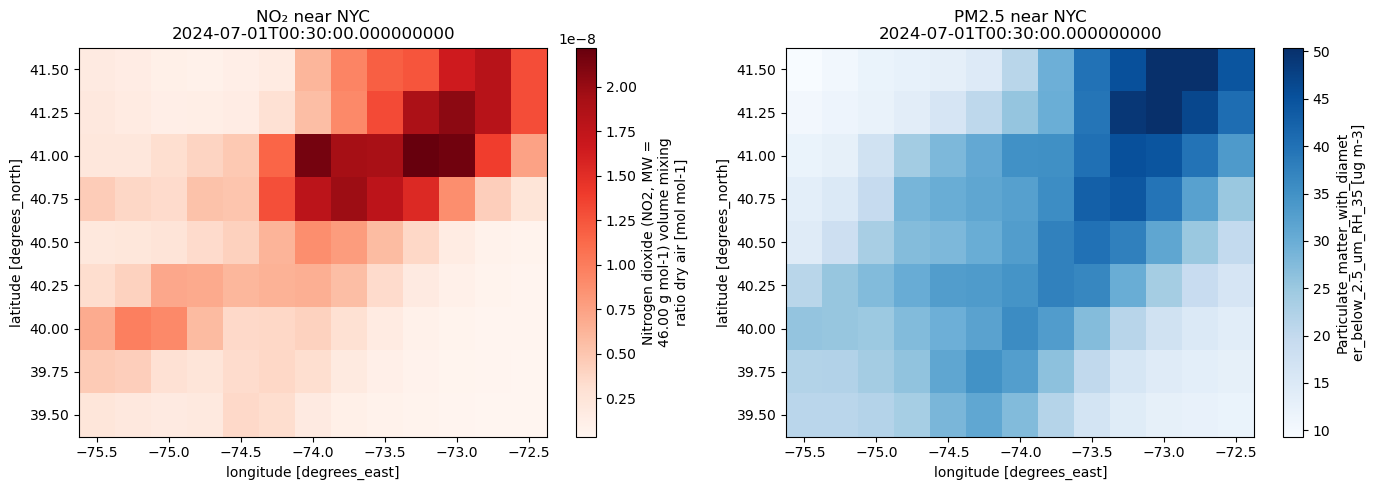

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

no2_map.plot(ax=axes[0], cmap="Reds")
axes[0].set_title(f"NO₂ near NYC\n{sample_time}")

pm25_map.plot(ax=axes[1], cmap="Blues")
axes[1].set_title(f"PM2.5 near NYC\n{sample_time}")

plt.tight_layout()
plt.show()

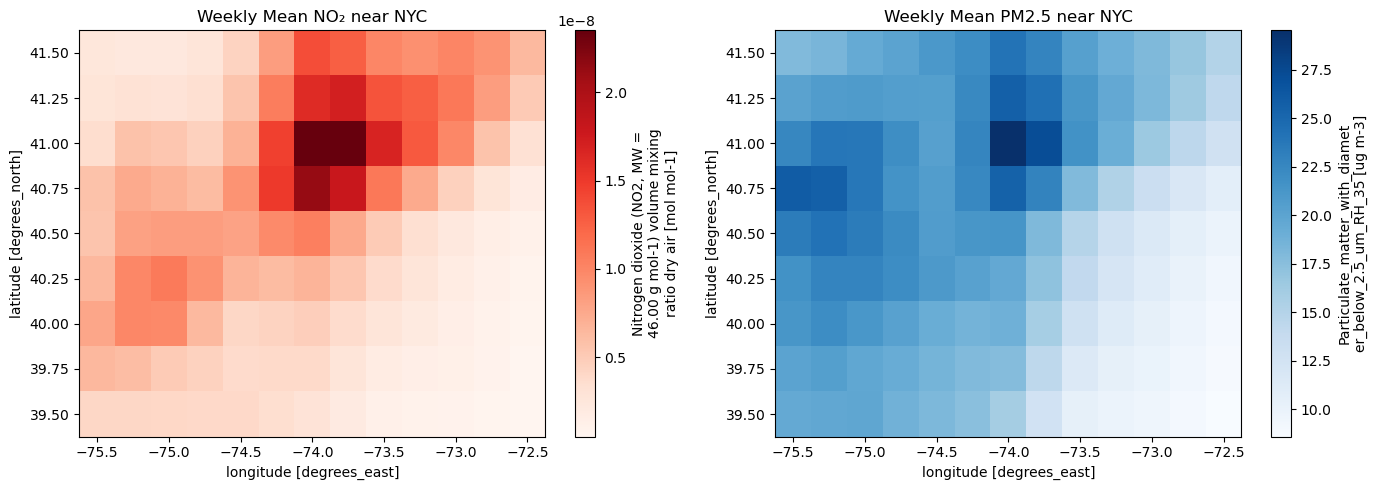

In [23]:
no2_week_mean = region_ds["NO2"].mean(dim="time").compute()
pm25_week_mean = region_ds["PM25_RH35_GCC"].mean(dim="time").compute()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

no2_week_mean.plot(ax=axes[0], cmap="Reds")
axes[0].set_title("Weekly Mean NO₂ near NYC")

pm25_week_mean.plot(ax=axes[1], cmap="Blues")
axes[1].set_title("Weekly Mean PM2.5 near NYC")

plt.tight_layout()
plt.show()

/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


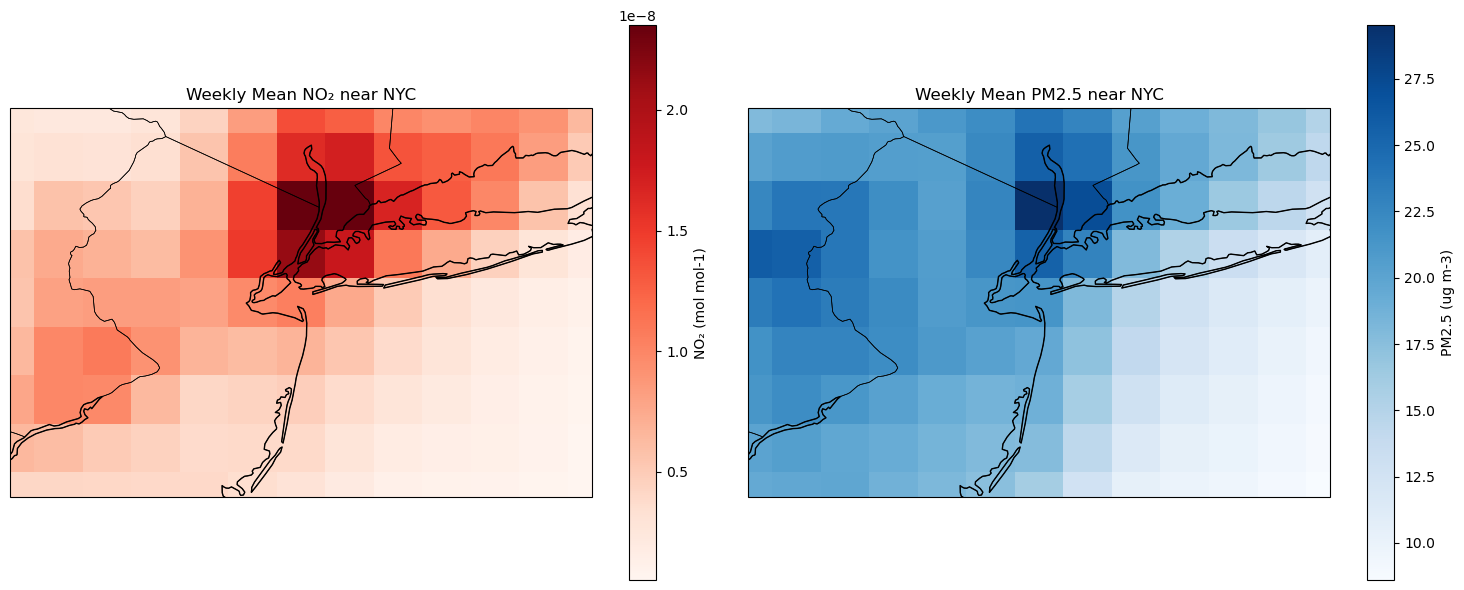

In [24]:
fig, axes = plt.subplots(
    1, 2, figsize=(15, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax in axes:
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

no2_week_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    cmap="Reds",
    cbar_kwargs={"label": f"NO₂ ({no2_week_mean.attrs.get('units', 'unknown units')})"}
)
axes[0].set_title("Weekly Mean NO₂ near NYC")

pm25_week_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    cmap="Blues",
    cbar_kwargs={"label": f"PM2.5 ({pm25_week_mean.attrs.get('units', 'unknown units')})"}
)
axes[1].set_title("Weekly Mean PM2.5 near NYC")

plt.tight_layout()
plt.show()